# Phase 2: Traditional ML — TF-IDF + SVM / Naive Bayes

This notebook implements traditional ML baselines — **TF-IDF + Linear SVM** (Aletras et al. 2016) and **TF-IDF + Naive Bayes** — applied to ECHR judgment **FACTS sections only**, for **Article 6** cases.

The label is **Article-6-specific**: was Article 6 found violated (`1`) or not (`0`)?

Two evaluation settings are used:
- **Random split** (75/25 stratified) — standard baseline
- **Temporal split** — train on older cases, test on newer cases (tests for temporal generalization)

## 1. Setup

In [1]:
%matplotlib inline
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords as nltk_stopwords

for pkg_path, pkg_name in [
    ('corpora/stopwords', 'stopwords'),
    ('corpora/wordnet',   'wordnet'),
    ('corpora/omw-1.4',  'omw-1.4'),
]:
    try:
        nltk.data.find(pkg_path)
    except LookupError:
        nltk.download(pkg_name)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/leondgarse/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/leondgarse/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Legal Tokenizer

Ported from the EDA notebook's shared lexical preprocessing pipeline.
Applies the same lemmatization and stopword filtering used in the Phase 1 TF-IDF analysis,
so that features are directly comparable across both phases.

Key steps:
- Manual lemma map for common irregular plurals in legal text (e.g. *authorities → authority*)
- WordNet lemmatizer with noun POS — normalises singular/plural noun forms
- Extended stopword list: NLTK English + legal boilerplate terms (`court`, `case`, `mr`, `mrs`, `ms`)

In [2]:
wnl = WordNetLemmatizer()

LEGAL_EXTRA_STOPWORDS = {"mr", "mrs", "ms", "court", "case"}
BASE_STOPWORDS        = set(nltk_stopwords.words("english"))
ALL_STOPWORDS         = BASE_STOPWORDS | LEGAL_EXTRA_STOPWORDS

MANUAL_LEMMA_MAP = {
    "applicants":   "applicant",
    "authorities":  "authority",
    "proceedings":  "proceeding",
    "judges":       "judge",
    "lawyers":      "lawyer",
    "officers":     "officer",
    "children":     "child",
    "women":        "woman",
    "men":          "man",
}

def normalize_token(tok: str) -> str:
    tok = tok.lower().strip()
    tok = MANUAL_LEMMA_MAP.get(tok, tok)
    if not re.search(r"[a-z]", tok):
        return ""
    tok = wnl.lemmatize(tok, pos="n")   # noun POS: singular/plural normalisation
    return tok

def legal_tokenizer(text: str):
    text   = str(text).lower()
    tokens = re.findall(r"[a-z']+", text)
    tokens = [normalize_token(t) for t in tokens]
    tokens = [t for t in tokens if t and len(t) > 2 and t not in ALL_STOPWORDS]
    return tokens

# Sanity check
sample = "The applicants' lawyers filed proceedings before the authorities."
print(legal_tokenizer(sample))

["applicants'", 'lawyer', 'filed', 'proceeding', 'authority']


## 3. Load & Filter Data

In [3]:
df_all = pd.read_csv('data/processed/processed.csv')
print(f'Full dataset: {len(df_all)} cases')
df_all.head(2)

Full dataset: 952 cases


,text,label,item_id,respondent,violation_articles,nonviolation_articles,year
0,I. THE CIRCUMSTANCES OF THE CASE4. The applicants are:1) Ms Bilat Akhmatkhanova_ who was born in 1956_2) Mr Sharpudi...,1,001-100029,RUS,3;5,NaN,2010
1,I. THE CIRCUMSTANCES OF THE CASE5. The applicants were born in 1962 and 1967 respectively and are now serving their ...,1,001-100040,RUS,5;6,NaN,2010


In [4]:
def contains_article(series, article='6'):
    """Return boolean mask: rows where `article` appears in a semicolon-delimited column."""
    return series.astype(str).str.split(';').apply(lambda arts: article in arts)

art6_violated    = contains_article(df_all['violation_articles'],    '6')
art6_notviolated = contains_article(df_all['nonviolation_articles'], '6')

df = df_all[art6_violated | art6_notviolated].copy()
df['label_art6'] = art6_violated[df.index].astype(int)

print(f'Article 6 cases: {len(df)}')
print(f'Label distribution:\n{df["label_art6"].value_counts().rename({1: "Violation", 0: "No violation"})}')

Article 6 cases: 436
Label distribution:
label_art6
Violation       320
No violation    116
Name: count, dtype: int64


In [5]:
print('Year range:', df['year'].min(), '\u2013', df['year'].max())
print()
print('Cases by respondent:')
print(df.groupby('respondent')['label_art6'].value_counts().unstack(fill_value=0)
        .rename(columns={0: 'No violation', 1: 'Violation'}))

Year range: 1983 – 2026

Cases by respondent:
label_art6  No violation  Violation
respondent                         
GBR                   52         96
RUS                   39        128
TUR                   25         96


## 4. TF-IDF Feature Extraction

Features are extracted from the **FACTS section only** using `legal_tokenizer` — the same pipeline as the Phase 1 EDA.

Parameters: `min_df=3`, `max_df=0.90`, `sublinear_tf=True`, `ngram_range=(1, 2)`

In [6]:
def make_tfidf():
    """TfidfVectorizer using the shared legal_tokenizer."""
    return TfidfVectorizer(
        tokenizer=legal_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        min_df=3,
        max_df=0.90,
        sublinear_tf=True,
        ngram_range=(1, 2),
    )

X = df['text'].values
y = df['label_art6'].values

_v = make_tfidf().fit(X)
print(f'Vocabulary size: {len(_v.vocabulary_):,} n-grams')

Vocabulary size: 16,681 n-grams


## 5. Hyperparameter Search — SVM `C`

Grid search over `C` using 5-fold stratified cross-validation on the training split.
Optimises for macro-F1 to account for class imbalance (Violation : No Violation ≈ 73% : 27%).

In [7]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {len(X_train_r)}  |  Test: {len(X_test_r)}')

pipe_gs = Pipeline([
    ('tfidf', make_tfidf()),
    ('svm',   LinearSVC(max_iter=2000, random_state=RANDOM_STATE)),
])

param_grid = {'svm__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gs = GridSearchCV(pipe_gs, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, refit=True)
gs.fit(X_train_r, y_train_r)

print(f'\nBest C: {gs.best_params_["svm__C"]}  |  CV macro-F1: {gs.best_score_:.3f}')

Train: 327  |  Test: 109

Best C: 10.0  |  CV macro-F1: 0.642


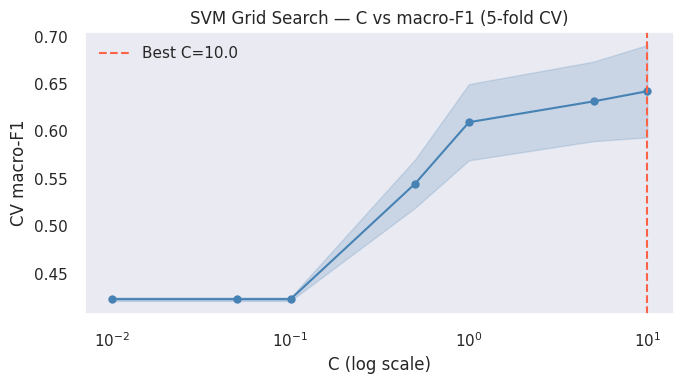

In [8]:
results_gs = pd.DataFrame(gs.cv_results_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(results_gs['param_svm__C'], results_gs['mean_test_score'], marker='o', color='steelblue')
ax.fill_between(
    results_gs['param_svm__C'],
    results_gs['mean_test_score'] - results_gs['std_test_score'],
    results_gs['mean_test_score'] + results_gs['std_test_score'],
    alpha=0.2, color='steelblue'
)
ax.axvline(gs.best_params_['svm__C'], color='tomato', linestyle='--',
           label=f'Best C={gs.best_params_["svm__C"]}')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('CV macro-F1')
ax.set_title('SVM Grid Search \u2014 C vs macro-F1 (5-fold CV)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluation — Random Split (75/25)

In [9]:
BEST_C = gs.best_params_['svm__C']

pipeline_svm = Pipeline([
    ('tfidf', make_tfidf()),
    ('svm',   LinearSVC(C=BEST_C, max_iter=2000, random_state=RANDOM_STATE)),
])
pipeline_svm.fit(X_train_r, y_train_r)
y_pred_svm_r = pipeline_svm.predict(X_test_r)

pipeline_nb = Pipeline([
    ('tfidf', make_tfidf()),
    ('nb',    ComplementNB()),
])
pipeline_nb.fit(X_train_r, y_train_r)
y_pred_nb_r = pipeline_nb.predict(X_test_r)

print(f'=== SVM (C={BEST_C}) \u2014 Random Split ===')
print(classification_report(y_test_r, y_pred_svm_r, target_names=['No Violation', 'Violation']))
print('=== Naive Bayes (Complement NB) \u2014 Random Split ===')
print(classification_report(y_test_r, y_pred_nb_r, target_names=['No Violation', 'Violation']))

=== SVM (C=10.0) — Random Split ===
              precision    recall  f1-score   support

No Violation       0.62      0.45      0.52        29
   Violation       0.82      0.90      0.86        80

    accuracy                           0.78       109
   macro avg       0.72      0.67      0.69       109
weighted avg       0.77      0.78      0.77       109

=== Naive Bayes (Complement NB) — Random Split ===
              precision    recall  f1-score   support

No Violation       0.00      0.00      0.00        29
   Violation       0.73      1.00      0.85        80

    accuracy                           0.73       109
   macro avg       0.37      0.50      0.42       109
weighted avg       0.54      0.73      0.62       109



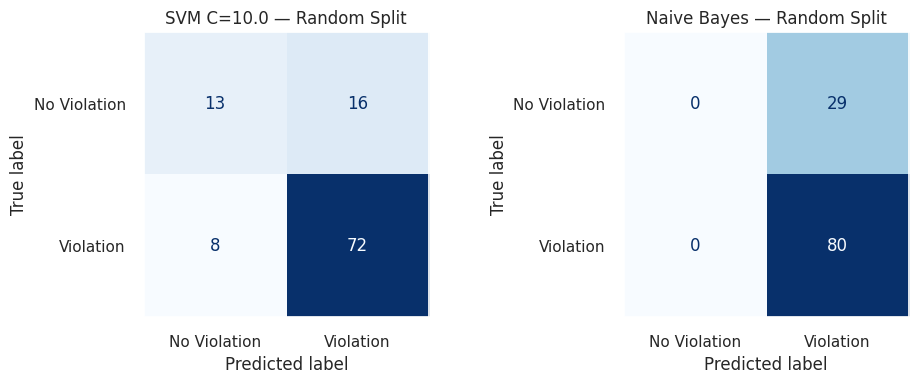

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title in [
    (axes[0], y_pred_svm_r, f'SVM C={BEST_C} \u2014 Random Split'),
    (axes[1], y_pred_nb_r,  'Naive Bayes \u2014 Random Split'),
]:
    ConfusionMatrixDisplay(confusion_matrix(y_test_r, y_pred),
                           display_labels=['No Violation', 'Violation']
                          ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 7. Evaluation — Temporal Split

Train on cases before the 75th-percentile year, test on cases from that year onwards.
Tests whether the model generalises to future cases or overfits to era-specific language.

In [11]:
split_year = int(np.percentile(df['year'].dropna(), 75))
print(f'Temporal split year: {split_year}')
print(f'  Train (< {split_year}): {(df["year"] < split_year).sum()} cases')
print(f'  Test  (\u2265 {split_year}): {(df["year"] >= split_year).sum()} cases')

train_mask = df['year'] < split_year
test_mask  = df['year'] >= split_year
X_train_t  = df.loc[train_mask, 'text'].values
y_train_t  = df.loc[train_mask, 'label_art6'].values
X_test_t   = df.loc[test_mask,  'text'].values
y_test_t   = df.loc[test_mask,  'label_art6'].values

Temporal split year: 2012
  Train (< 2012): 278 cases
  Test  (≥ 2012): 158 cases


In [12]:
pipeline_svm_t = Pipeline([
    ('tfidf', make_tfidf()),
    ('svm',   LinearSVC(C=BEST_C, max_iter=2000, random_state=RANDOM_STATE)),
])
pipeline_svm_t.fit(X_train_t, y_train_t)
y_pred_svm_t = pipeline_svm_t.predict(X_test_t)

pipeline_nb_t = Pipeline([
    ('tfidf', make_tfidf()),
    ('nb',    ComplementNB()),
])
pipeline_nb_t.fit(X_train_t, y_train_t)
y_pred_nb_t = pipeline_nb_t.predict(X_test_t)

print(f'=== SVM (C={BEST_C}) \u2014 Temporal Split (test \u2265 {split_year}) ===')
print(classification_report(y_test_t, y_pred_svm_t, target_names=['No Violation', 'Violation']))
print(f'=== Naive Bayes \u2014 Temporal Split (test \u2265 {split_year}) ===')
print(classification_report(y_test_t, y_pred_nb_t, target_names=['No Violation', 'Violation']))

=== SVM (C=10.0) — Temporal Split (test ≥ 2012) ===
              precision    recall  f1-score   support

No Violation       0.62      0.19      0.29        52
   Violation       0.70      0.94      0.81       106

    accuracy                           0.70       158
   macro avg       0.66      0.57      0.55       158
weighted avg       0.68      0.70      0.64       158

=== Naive Bayes — Temporal Split (test ≥ 2012) ===
              precision    recall  f1-score   support

No Violation       0.00      0.00      0.00        52
   Violation       0.67      1.00      0.80       106

    accuracy                           0.67       158
   macro avg       0.34      0.50      0.40       158
weighted avg       0.45      0.67      0.54       158



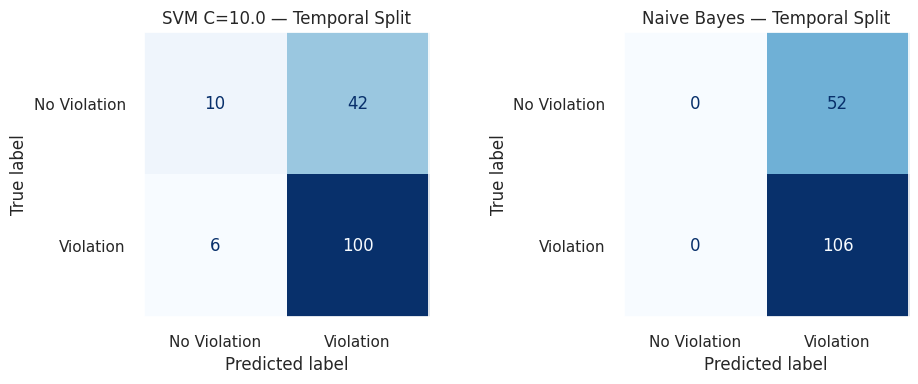

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_pred, title in [
    (axes[0], y_pred_svm_t, f'SVM C={BEST_C} \u2014 Temporal Split'),
    (axes[1], y_pred_nb_t,  'Naive Bayes \u2014 Temporal Split'),
]:
    ConfusionMatrixDisplay(confusion_matrix(y_test_t, y_pred),
                           display_labels=['No Violation', 'Violation']
                          ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 8. Model Comparison

In [14]:
rows = [
    ('SVM',         'Random',   y_test_r, y_pred_svm_r),
    ('SVM',         'Temporal', y_test_t, y_pred_svm_t),
    ('Naive Bayes', 'Random',   y_test_r, y_pred_nb_r),
    ('Naive Bayes', 'Temporal', y_test_t, y_pred_nb_t),
]

comparison = pd.DataFrame([
    {
        'Model':             model,
        'Split':             split,
        'Accuracy':          round(accuracy_score(yt, yp), 3),
        'Macro-F1':          round(f1_score(yt, yp, average='macro'), 3),
        'F1 (Violation)':    round(f1_score(yt, yp, pos_label=1, average='binary'), 3),
        'F1 (No Violation)': round(f1_score(yt, yp, pos_label=0, average='binary'), 3),
    }
    for model, split, yt, yp in rows
])

display(comparison.set_index(['Model', 'Split']))

Accuracy  Macro-F1  F1 (Violation)  F1 (No Violation)
Model       Split                                                          
SVM         Random       0.780     0.689           0.857              0.520
            Temporal     0.696     0.550           0.806              0.294
Naive Bayes Random       0.734     0.423           0.847              0.000
            Temporal     0.671     0.402           0.803              0.000

## 9. Bias Analysis — Per-Country Performance

In [15]:
indices = np.arange(len(df))
_, test_idx = train_test_split(indices, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

test_df = df.iloc[test_idx].copy()
test_df['pred_svm'] = y_pred_svm_r
test_df['pred_nb']  = y_pred_nb_r

country_stats = test_df.groupby('respondent').agg(
    n_cases=('label_art6', 'count'),
    violation_rate=('label_art6', 'mean'),
    acc_svm=('pred_svm', lambda s: (s == test_df.loc[s.index, 'label_art6']).mean()),
    acc_nb= ('pred_nb',  lambda s: (s == test_df.loc[s.index, 'label_art6']).mean()),
).round(3)

print('Per-country accuracy on test set (random split):')
display(country_stats)

Per-country accuracy on test set (random split):


,n_cases,violation_rate,acc_svm,acc_nb
respondent,,,,
GBR,44,0.659,0.659,0.659
RUS,38,0.763,0.816,0.763
TUR,27,0.815,0.926,0.815


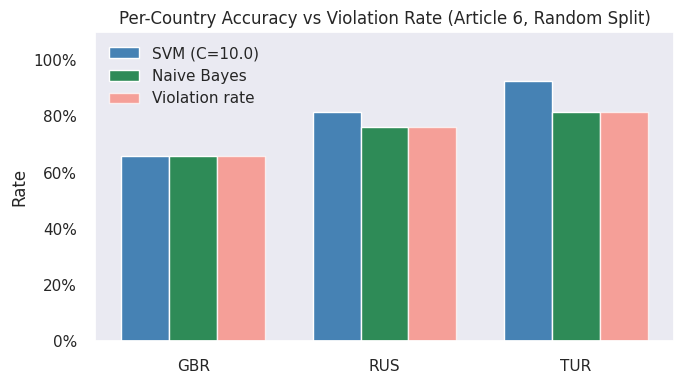

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
countries = country_stats.index.tolist()
x = np.arange(len(countries))
width = 0.25

ax.bar(x - width,   country_stats['acc_svm'],        width, label=f'SVM (C={BEST_C})', color='steelblue')
ax.bar(x,           country_stats['acc_nb'],         width, label='Naive Bayes',        color='seagreen')
ax.bar(x + width,   country_stats['violation_rate'], width, label='Violation rate',     color='salmon', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.set_ylabel('Rate')
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Per-Country Accuracy vs Violation Rate (Article 6, Random Split)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Top Discriminating Features (SVM)

Presence of country names or procedural boilerplate in the highest-weight features is direct evidence of spurious correlation.

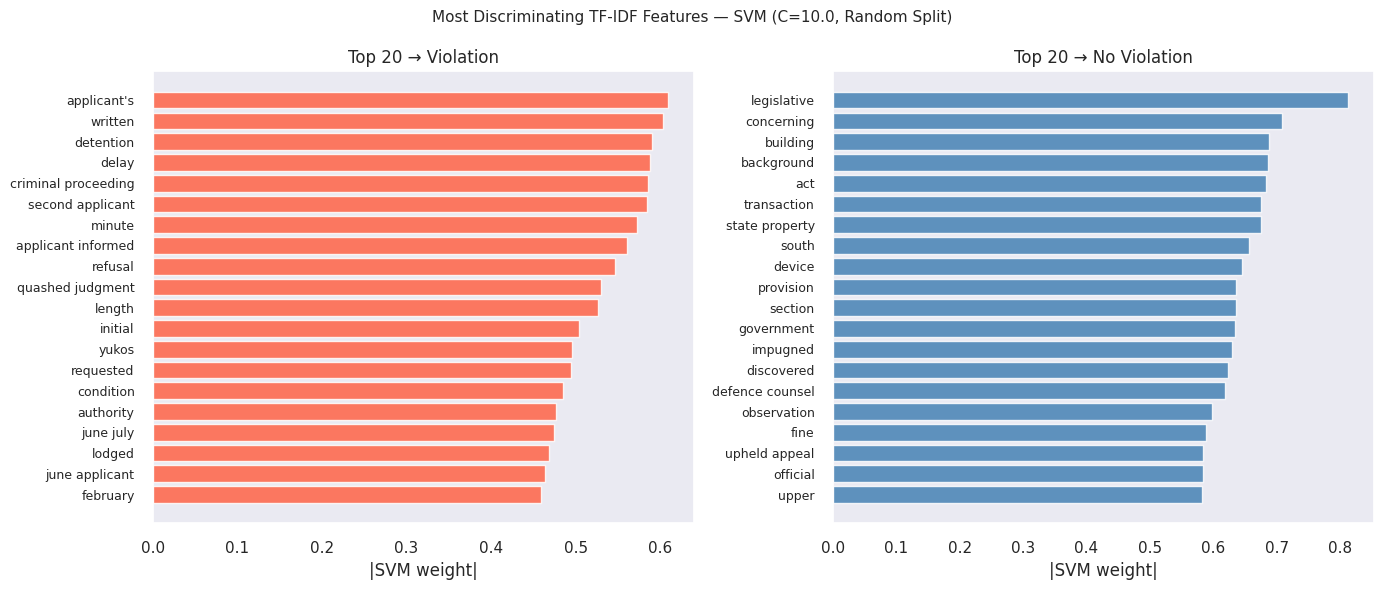

In [17]:
feature_names = np.array(pipeline_svm.named_steps['tfidf'].get_feature_names_out())
coef          = pipeline_svm.named_steps['svm'].coef_[0]

N = 20
top_pos_idx = np.argsort(coef)[-N:][::-1]
top_neg_idx = np.argsort(coef)[:N]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, idx, title, color in [
    (axes[0], top_pos_idx, f'Top {N} \u2192 Violation',    'tomato'),
    (axes[1], top_neg_idx, f'Top {N} \u2192 No Violation', 'steelblue'),
]:
    terms  = feature_names[idx]
    values = np.abs(coef[idx])
    ax.barh(range(N), values[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(N))
    ax.set_yticklabels(terms[::-1], fontsize=9)
    ax.set_xlabel('|SVM weight|')
    ax.set_title(title)

plt.suptitle(f'Most Discriminating TF-IDF Features \u2014 SVM (C={BEST_C}, Random Split)', fontsize=11)
plt.tight_layout()
plt.show()

## 11. Summary

**Interpretation guide:**
- A large gap between random-split and temporal-split accuracy suggests the model learns era-specific language rather than legal principles.
- High per-country variance — especially accuracy closely tracking the violation rate — suggests the model exploits class base rates rather than case facts.
- Presence of procedural/boilerplate terms or country names in the top SVM features is direct evidence of spurious correlation.
- Complement NB is included as a comparison: it handles class imbalance well but assumes feature independence, unlike SVM.